<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_LLMs_in_Qualitative_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Dependencies & NLP Environment Setup]
!pip install -q sentence-transformers scikit-learn pandas matplotlib seaborn torch

import re
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple, Any
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import classification_report, confusion_matrix

print("Initializing Reflexive Qualitative LLM Interlocutor Probe...")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Execution Device: {device}")

Initializing Reflexive Qualitative LLM Interlocutor Probe...
Execution Device: cuda


In [2]:
# [CELL 2 - Ethical Privacy & Participant Protection Guardrail Layer]

class QualitativePrivacyScrubber:
    """
    Implements participant data protection guardrails as emphasized by Schroeder et al. (2025/2026).
    Scrubs Personally Identifiable Information (PII) before passing text to model pipelines.
    """
    def __init__(self):
        self.patterns = {
            "EMAIL": r'[\w\.-]+@[\w\.-]+\.\w+',
            "PHONE": r'\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b',
            "NAME": r'\b(P_\d+|Participant_\d+|Dr\.\s+[A-Z][a-z]+|[A-Z][a-z]+\s+[A-Z][a-z]+)\b',
            "LOCATION": r'\b(University of [A-Z][a-z]+|Cornell|MIT|Michigan|Rutgers|Boston|Chicago)\b'
        }

    def sanitize_transcript(self, text: str) -> Dict[str, Any]:
        sanitized_text = text
        redactions = 0

        for ptype, pattern in self.patterns.items():
            matches = re.findall(pattern, sanitized_text)
            if matches:
                redactions += len(matches)
                sanitized_text = re.sub(pattern, f"[{ptype}_REDACTED]", sanitized_text)

        return {
            "original_text": text,
            "sanitized_text": sanitized_text,
            "redaction_count": redactions
        }

scrubber = QualitativePrivacyScrubber()

# Quick Guardrail Sanity Check
raw_sample = "Participant_04 (p4@cornell.edu at Cornell) expressed anxiety about AI ethics."
sanitized_res = scrubber.sanitize_transcript(raw_sample)
print("Raw Input:      ", sanitized_res["original_text"])
print("Sanitized Output:", sanitized_res["sanitized_text"])
print(f"Redactions Made: {sanitized_res['redaction_count']}")

Raw Input:       Participant_04 (p4@cornell.edu at Cornell) expressed anxiety about AI ethics.
Sanitized Output: [NAME_REDACTED] ([EMAIL_REDACTED] at [LOCATION_REDACTED]) expressed anxiety about AI ethics.
Redactions Made: 3


In [3]:
# [CELL 3 - Qualitative Codebook & Reflexive Interlocutor Engine]

QUALITATIVE_CODEBOOK = {
    "interlocutor_dialogue": {
        "definition": "Using LLMs as brainstorm partners, counter-argument generators, or dialogic interlocutors to spark analytical reflection.",
        "anchors": [
            "I treat the LLM as a research assistant to challenge my assumptions about the data.",
            "Using AI to play devil's advocate helped me refine my qualitative coding taxonomy.",
            "The model acts as a sounding board during initial open coding and theme exploration."
        ]
    },
    "ethical_tensions": {
        "definition": "Concerns regarding participant privacy, consent, institutional guidelines, and intellectual authorship.",
        "anchors": [
            "Uploading raw participant interview transcripts to commercial LLM APIs violates IRB protocol.",
            "I worry about loss of reflexivity and hallucinated themes in qualitative analysis.",
            "We lack formal guidelines on proper citation and disclosure of AI assistance in qualitative papers."
        ]
    },
    "analytical_efficiency": {
        "definition": "Leveraging LLMs for rapidly summarizing, organizing, filtering, or preliminary thematic structuring.",
        "anchors": [
            "Synthesizing 50 long interview transcripts into high-level summaries saved weeks of effort.",
            "Automating first-pass entity extraction allowed us to focus on deep reflexive interpretation.",
            "The LLM accelerated transcript sorting across large demographic cohorts."
        ]
    },
    "epistemic_friction": {
        "definition": "Skeptical posture toward model outputs failing to capture nuance, cultural context, or systemic power dynamics.",
        "anchors": [
            "The LLM flattens marginal community perspectives into generic corporate summaries.",
            "AI missing subtle sarcasm and localized cultural metaphors limits its inductive utility.",
            "Quantitative scoring of qualitative text strips away the participant's lived experience."
        ]
    }
}

class ReflexiveQualitativeEngine:
    """
    Semantic qualitative interlocutor engine grounded in Schroeder et al.'s design principles.
    Provides semantic code matching, confidence scores, and reflexive audit logs.
    """
    def __init__(self, codebook: Dict[str, Dict[str, Any]], model_name: str = "all-MiniLM-L6-v2"):
        self.codebook = codebook
        self.model = SentenceTransformer(model_name)
        self.category_names = list(codebook.keys())

        self.category_embeddings = {}
        for cat, data in codebook.items():
            corpus = [data["definition"]] + data["anchors"]
            embeddings = self.model.encode(corpus, convert_to_tensor=True)
            self.category_embeddings[cat] = torch.mean(embeddings, dim=0, keepdim=True)

    def analyze_utterance(self, text: str, privacy_engine: QualitativePrivacyScrubber) -> Dict[str, Any]:
        # 1. Apply Privacy Guardrail
        sanitized = privacy_engine.sanitize_transcript(text)
        clean_text = sanitized["sanitized_text"]

        # 2. Semantic Analysis
        embedding = self.model.encode(clean_text, convert_to_tensor=True)
        similarities = {}
        for cat, cat_emb in self.category_embeddings.items():
            sim = util.cos_sim(embedding, cat_emb).item()
            similarities[cat] = sim

        predicted_code = max(similarities, key=similarities.get)
        confidence = similarities[predicted_code]

        # 3. Reflexive Audit Trail Generation
        sorted_sims = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
        top_diff = sorted_sims[0][1] - sorted_sims[1][1]
        ambiguity_flag = "HIGH_AMBIGUITY" if top_diff < 0.08 else "CONFIDENT_MATCH"

        audit_trail = f"Primary code '{predicted_code}' selected (sim={confidence:.3f}). Second best: '{sorted_sims[1][0]}' (sim={sorted_sims[1][1]:.3f}). Delta={top_diff:.3f} [{ambiguity_flag}]."

        return {
            "original_text": text,
            "clean_text": clean_text,
            "predicted_code": predicted_code,
            "confidence_score": confidence,
            "ambiguity_flag": ambiguity_flag,
            "audit_trail": audit_trail,
            "all_similarities": similarities
        }

qual_engine = ReflexiveQualitativeEngine(QUALITATIVE_CODEBOOK)
print(f"Loaded {len(QUALITATIVE_CODEBOOK)} qualitative research themes into the codebook engine.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded 4 qualitative research themes into the codebook engine.


In [4]:
# [CELL 4 - Out-of-Sample Qualitative Interview Dataset]

QUALITATIVE_INTERVIEW_BENCHMARK = [
    # Interlocutor Dialogue
    {"text": "I used ChatGPT as a conversational partner to push back against my initial thematic interpretations of the transcripts.", "ground_truth": "interlocutor_dialogue", "phase": "Data Analysis"},
    {"text": "Bouncing ideas off the LLM helped me uncover alternative explanations for why participants resisted the software.", "ground_truth": "interlocutor_dialogue", "phase": "Reflexive Synthesis"},

    # Ethical Tensions
    {"text": "Participant_09 was concerned about data leakage, so uploading raw interviews to external server endpoints was completely out of the question.", "ground_truth": "ethical_tensions", "phase": "Data Handling"},
    {"text": "There is a severe lack of institutional guidance on whether AI-assisted transcript coding requires explicit consent.", "ground_truth": "ethical_tensions", "phase": "Research Governance"},

    # Analytical Efficiency
    {"text": "Summarizing 30 long interview recordings using model prompts allowed our team to map broad thematic clusters in two days.", "ground_truth": "analytical_efficiency", "phase": "Preliminary Coding"},
    {"text": "The automated system quickly structured unstructured participant feedback into neat demographic categories.", "ground_truth": "analytical_efficiency", "phase": "Data Organization"},

    # Epistemic Friction
    {"text": "The LLM completely missed the cultural nuance in how participants described community solidarity during crises.", "ground_truth": "epistemic_friction", "phase": "Interpretation"},
    {"text": "Automated coding outputs felt generic and flattened the lived experiences of vulnerable populations.", "ground_truth": "epistemic_friction", "phase": "Interpretation"},

    # Additional Held-Out Transcripts
    {"text": "Asking the model to generate counter-examples forced me to inspect negative cases in my dataset.", "ground_truth": "interlocutor_dialogue", "phase": "Reflexive Synthesis"},
    {"text": "We must redact all participant email addresses and university names before using cloud AI services.", "ground_truth": "ethical_tensions", "phase": "Data Handling"},
    {"text": "Using automated models for initial filtering sped up our systematic literature review phase significantly.", "ground_truth": "analytical_efficiency", "phase": "Preliminary Coding"},
    {"text": "Models lack empathy and cannot capture systemic oppression or power dynamics present in qualitative narratives.", "ground_truth": "epistemic_friction", "phase": "Interpretation"}
]

benchmark_df = pd.DataFrame(QUALITATIVE_INTERVIEW_BENCHMARK)
print(f"Loaded {len(benchmark_df)} out-of-sample interview transcripts for evaluation.")

Loaded 12 out-of-sample interview transcripts for evaluation.


In [5]:
# [CELL 5 - Evaluation Engine & Reflexive Metrics]
from typing import Tuple

def evaluate_qualitative_pipeline(
    df: pd.DataFrame,
    engine: ReflexiveQualitativeEngine,
    privacy_scrubber: QualitativePrivacyScrubber
) -> Tuple[pd.DataFrame, Dict[str, Any]]:

    predictions = []
    confidences = []
    flags = []
    audit_logs = []

    for _, row in df.iterrows():
        out = engine.analyze_utterance(row["text"], privacy_scrubber)
        predictions.append(out["predicted_code"])
        confidences.append(out["confidence_score"])
        flags.append(out["ambiguity_flag"])
        audit_logs.append(out["audit_trail"])

    df["predicted_code"] = predictions
    df["confidence_score"] = confidences
    df["ambiguity_flag"] = flags
    df["audit_trail"] = audit_logs
    df["is_correct"] = (df["ground_truth"] == df["predicted_code"])

    categories = engine.category_names
    report = classification_report(
        df["ground_truth"],
        df["predicted_code"],
        labels=categories,
        zero_division=0,
        output_dict=True
    )

    return df, report

eval_df, metrics_report = evaluate_qualitative_pipeline(benchmark_df, qual_engine, scrubber)

print("============================================================")
print("QUALITATIVE LLM INTERLOCUTOR BENCHMARK REPORT")
print("============================================================")
report_table = pd.DataFrame(metrics_report).transpose()
print(report_table.to_string())
print("============================================================")
print(f"Overall Categorization Accuracy: {metrics_report['accuracy']*100:.1f}%")
print(f"Macro F1-Score:                 {metrics_report['macro avg']['f1-score']:.4f}")
print("============================================================")

print("\nSAMPLE REFLEXIVE AUDIT LOG:")
print(eval_df[["text", "predicted_code", "ambiguity_flag", "audit_trail"]].iloc[0].to_dict())

QUALITATIVE LLM INTERLOCUTOR BENCHMARK REPORT
                       precision    recall  f1-score    support
interlocutor_dialogue   0.666667  0.666667  0.666667   3.000000
ethical_tensions        1.000000  1.000000  1.000000   3.000000
analytical_efficiency   0.750000  1.000000  0.857143   3.000000
epistemic_friction      1.000000  0.666667  0.800000   3.000000
accuracy                0.833333  0.833333  0.833333   0.833333
macro avg               0.854167  0.833333  0.830952  12.000000
weighted avg            0.854167  0.833333  0.830952  12.000000
Overall Categorization Accuracy: 83.3%
Macro F1-Score:                 0.8310

SAMPLE REFLEXIVE AUDIT LOG:
{'text': 'I used ChatGPT as a conversational partner to push back against my initial thematic interpretations of the transcripts.', 'predicted_code': 'analytical_efficiency', 'ambiguity_flag': 'HIGH_AMBIGUITY', 'audit_trail': "Primary code 'analytical_efficiency' selected (sim=0.513). Second best: 'ethical_tensions' (sim=0.471). Delt

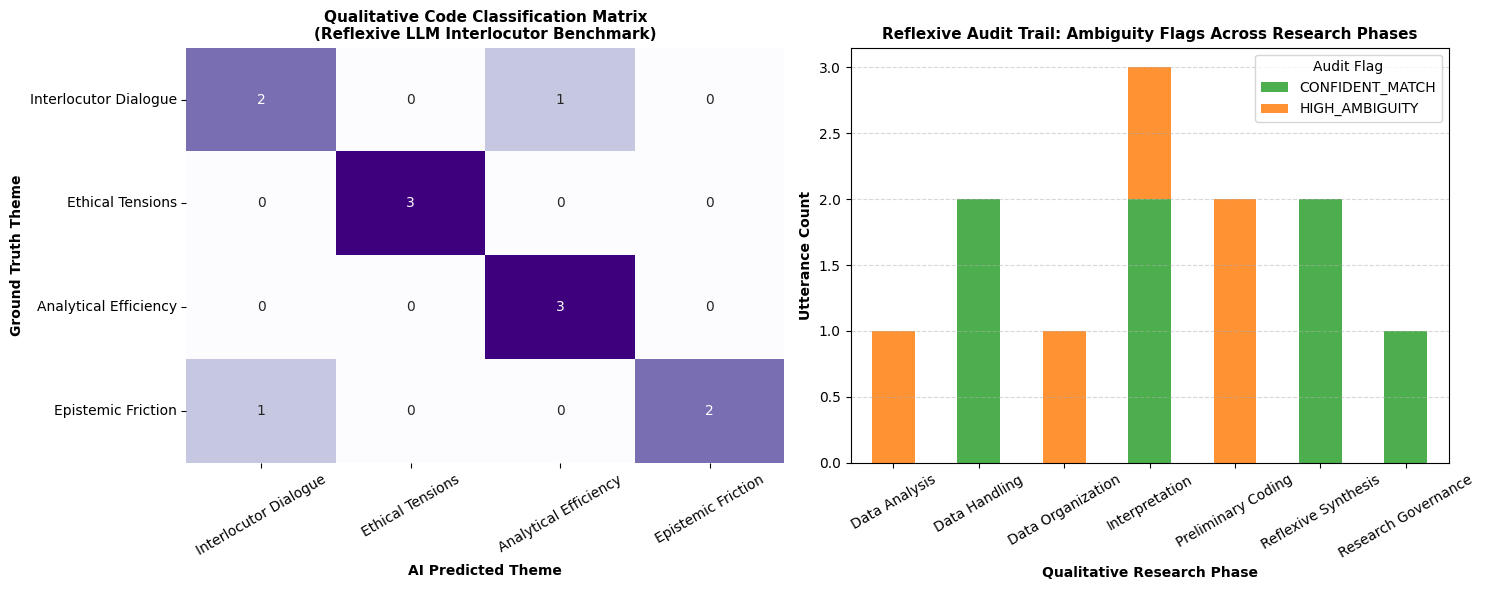

In [6]:
# [CELL 6 - Publication-Grade Visual Dashboard]

def plot_qualitative_research_dashboard(df: pd.DataFrame, categories: List[str]):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Confusion Matrix
    cm = confusion_matrix(df["ground_truth"], df["predicted_code"], labels=categories)
    labels_formatted = [c.replace("_", " ").title() for c in categories]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels_formatted, yticklabels=labels_formatted, ax=ax1, cbar=False)
    ax1.set_title("Qualitative Code Classification Matrix\n(Reflexive LLM Interlocutor Benchmark)", fontsize=11, fontweight='bold')
    ax1.set_xlabel("AI Predicted Theme", fontsize=10, fontweight='bold')
    ax1.set_ylabel("Ground Truth Theme", fontsize=10, fontweight='bold')
    ax1.tick_params(axis='x', rotation=30)

    # 2. Ambiguity & Confidence across Research Phases
    phase_summary = df.groupby(["phase", "ambiguity_flag"]).size().unstack(fill_value=0)
    phase_summary.plot(kind='bar', stacked=True, ax=ax2, color=['#2ca02c', '#ff7f0e'], alpha=0.85)
    ax2.set_title("Reflexive Audit Trail: Ambiguity Flags Across Research Phases", fontsize=11, fontweight='bold')
    ax2.set_xlabel("Qualitative Research Phase", fontsize=10, fontweight='bold')
    ax2.set_ylabel("Utterance Count", fontsize=10, fontweight='bold')
    ax2.legend(title="Audit Flag", loc='upper right')
    ax2.tick_params(axis='x', rotation=30)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_qualitative_research_dashboard(eval_df, qual_engine.category_names)